K=2: Inertia=111484.44, Silhouette=0.1818
K=3: Inertia=100534.17, Silhouette=0.1355
K=4: Inertia=95678.20, Silhouette=0.1116
K=5: Inertia=91820.17, Silhouette=0.1077
K=6: Inertia=88245.46, Silhouette=0.1044
K=7: Inertia=85176.67, Silhouette=0.0956


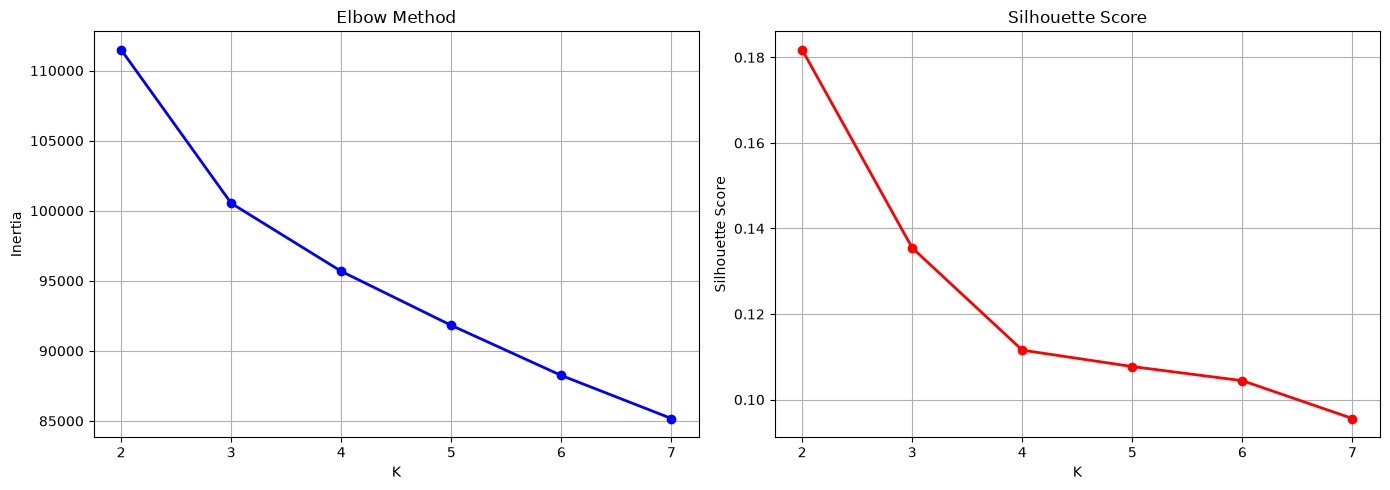


Training final K-Means with K=3...

Cluster composition (approval rate per cluster):
  Cluster 0: 1244 applicants, 84.32% approved
  Cluster 1: 1096 applicants, 8.94% approved
  Cluster 2: 1660 applicants, 85.78% approved

✅ K-Means saved.


In [1]:
import numpy as np
import pandas as pd
import joblib
import os
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

BASE = r'C:\Users\Anushka Thite\Desktop\smart-loan-system'
PROCESSED_DIR = os.path.join(BASE, 'data', 'processed')
MODELS_DIR = os.path.join(BASE, 'models')

X_test = np.load(os.path.join(PROCESSED_DIR, 'X_test.npy'))
y_test = np.load(os.path.join(PROCESSED_DIR, 'y_test.npy'))

# Find optimal K — Elbow + Silhouette
inertias = []
sil_scores = []
K_range = range(2, 8)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_test)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_test, labels))
    print(f"K={k}: Inertia={km.inertia_:.2f}, Silhouette={sil_scores[-1]:.4f}")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_range, inertias, 'bo-', linewidth=2)
axes[0].set_xlabel('K')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method')
axes[0].grid(True)

axes[1].plot(K_range, sil_scores, 'ro-', linewidth=2)
axes[1].set_xlabel('K')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score')
axes[1].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(MODELS_DIR, 'clustering_analysis.png'), dpi=100)
plt.show()

# Final K-Means with K=3 (Low/Medium/High risk)
print("\nTraining final K-Means with K=3...")
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
labels = kmeans.fit_predict(X_test)

joblib.dump(kmeans, os.path.join(MODELS_DIR, 'kmeans.pkl'))
np.save(os.path.join(MODELS_DIR, 'cluster_labels.npy'), labels)

# Analyze segments
df_clusters = pd.DataFrame({'cluster': labels, 'actual': y_test})
print("\nCluster composition (approval rate per cluster):")
for c in range(3):
    subset = df_clusters[df_clusters['cluster'] == c]
    approval_rate = subset['actual'].mean()
    print(f"  Cluster {c}: {len(subset)} applicants, {approval_rate:.2%} approved")

print("\n✅ K-Means saved.")